<a href="https://colab.research.google.com/github/luquelab/team_superstars_BIL552/blob/main/Bionformatic_Pipeline_Superstars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bioinformatics Pipeline

---
## Table of Contents
- [Example: M.leidyi](#overview)
- [Requirements](#requirements)
- [Input Data](#input-data)
- [Pipeline Stages](#pipeline-stages)
  - [1. Install & Import Packages](#1-install--import-packages)
  - [2. Input or Fetch Data](#2-input-or-fetch-data)
  - [3. Store FASTA File](#3-store-fasta-file)
  - [4. Calculate Physicochemical Properties](#4-calculate-physicochemical-properties)
  - [5. Create a Property Dictionary](#5-create-a-property-dictionary)
  - [6. Sequence Similarity](#6-sequence-similarity)
  - [7. Store Sequence Similarity](#7-store-sequence-similarity)
  - [8. Relationship Between Proteins — Dendrogram](#8-relationship-between-proteins--dendrogram)
  - [9. Relationship Outputs — Heatmaps](#9-relationship-outputs--heatmaps)
- [Output Summary](#output-summary)
- [Notes & Limitations](#notes--limitations)
---
## Example: M.leidyi
This pipeline takes protein sequences in FASTA format and produces:
- Per-protein physicochemical properties (molecular weight, isoelectric point, net charge, extinction coefficient, amino acid composition)
- An all-vs-all pairwise sequence similarity table using global alignment
- A hierarchical clustering dendrogram based on physicochemical features
- Three pairwise distance heatmaps: physicochemical, sequence-based, and combined
The example dataset contains six cathepsin-like proteins from *Mnemiopsis leidyi* (gene IDs: g-680, g-11155, g-15657, g-4430, g-15835, g-15451).
---
## Requirements
All dependencies are installed within the notebook. The pipeline runs on **Google Colab** (Python 3.12+).
| Package | Purpose |
|---|---|
| biopython (≥1.87) | FASTA parsing, protein analysis, pairwise alignment |
| pandas | Tabular data storage and display |
| numpy | Numerical operations |
| matplotlib | Dendrogram and plot rendering |
| seaborn | Heatmap visualization |
| scipy | Hierarchical clustering, pairwise distance calculation |
| scikit-learn | Feature scaling (StandardScaler, MinMaxScaler) |
| google.colab | File upload interface |
Install command (run automatically in the notebook):
bash
!pip install biopython

---
## Input Data
**Format:** FASTA (.fasta or .fa), containing one or more protein sequences.
**Example file:** Mnemiopsis_cathepsin_subset.fasta (~4,580 bytes, 6 sequences)
Each record should follow standard FASTA format:

>sequence_id optional description
MKVLILCLVVVTITVS...

Stop codons (*) are stripped automatically before analysis.
---
## Pipeline Stages
### 1. Install & Import Packages
Installs biopython and imports the core libraries needed throughout the notebook:
python
import google.colab.files as files
from pathlib import Path

### 2. Input or Fetch Data
Prompts the user to upload one or more FASTA files via the Colab file dialog:
python
uploaded = files.upload()

All uploaded filenames are stored in the uploaded dictionary for downstream use.
### 3. Store FASTA File
Reads each uploaded file into memory and stores the raw text content in fasta_data_dict, a dictionary keyed by filename:
python
fasta_data_dict[file_path] = f.read()

This step confirms the number of characters loaded per file and is required before any analysis steps.
### 4. Calculate Physicochemical Properties
Uses Bio.SeqUtils.ProtParam.ProteinAnalysis to compute the following for each sequence:
| Property | Description |
|---|---|
| **Length** | Number of amino acids |
| **Molecular Weight** | In Daltons (Da) |
| **Amino Acid Composition** | Per-residue counts for all 20 standard amino acids |
| **Isoelectric Point (pI)** | pH at which the protein carries no net charge |
| **Net Charge at pH 7.0** | Estimated charge under physiological conditions |
| **Extinction Coefficient** | Molar extinction (M⁻¹ cm⁻¹) for both reduced and oxidized cysteine states |
Results are printed to the console for each sequence.
### 5. Create a Property Dictionary
Aggregates the per-protein properties into a pandas DataFrame (properties_df) with one row per protein:
| Column | Description |
|---|---|
| Protein_ID | Sequence identifier from FASTA header |
| Length | Amino acid count |
| Molecular_Weight_Da | Molecular weight (Da) |
| Isoelectric_Point | pI value |
| Net_Charge_pH7 | Net charge at pH 7.0 |
| Extinction_Coeff_Reduced | Extinction coefficient (reduced cysteines) |
The DataFrame is displayed interactively and carried forward into clustering and heatmap steps.
### 6. Sequence Similarity
Performs all-vs-all **global pairwise alignment** using Bio.Align.PairwiseAligner (mode: global):
python
aligner = Align.PairwiseAligner()
aligner.mode = 'global'

For each unique protein pair, the pipeline reports:
- **Raw Score** — Absolute alignment score (positive = similar, negative = divergent)
- **Similarity Percentage** — Raw score normalized by the length of the longer sequence (score / max_len * 100)
> **Note:** Because this metric is not a true percent identity, it can be negative when mismatches and gaps dominate the alignment.
### 7. Store Sequence Similarity
Collects all pairwise alignment results into a pandas DataFrame (similarity_df):
| Column | Description |
|---|---|
| Protein_1 | First protein in the pair |
| Protein_2 | Second protein in the pair |
| Raw_Score | Biopython PairwiseAligner score |
| Similarity_Percentage | Normalized similarity metric |
The notebook also prints a plain-language explanation of how to interpret positive vs. negative scores.
### 8. Relationship Between Proteins — Dendrogram
Generates a **hierarchical clustering dendrogram** based on standardized physicochemical features using Ward's linkage method:
python
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_data)
Z = linkage(scaled_features, method='ward')

Features used for clustering: Length, Molecular_Weight_Da, Isoelectric_Point, Net_Charge_pH7, Extinction_Coeff_Reduced.
Standardization ensures that large-scale properties (e.g., molecular weight) do not dominate over small-scale ones (e.g., net charge). Proteins that merge at lower y-axis values are more physicochemically similar.
### 9. Relationship Outputs — Heatmaps
Generates three side-by-side normalized distance heatmaps (0 = identical, 1 = maximally dissimilar):
1. **Physicochemical Distances** — Euclidean distances in standardized feature space
2. **Sequence Similarity Distances** — Derived from pairwise alignment scores
3. **Combined Distances** — Average of the two above matrices
python
combined_dist_norm = (phys_dist_norm + seq_dist_norm) / 2.0

All matrices are normalized to [0, 1] using MinMaxScaler before display.
---
## Output Summary
| Output | Variable | Type |
|---|---|---|
| Physicochemical properties per protein | properties_df | pd.DataFrame |
| All-vs-all alignment scores | similarity_df | pd.DataFrame |
| Hierarchical clustering dendrogram | — | matplotlib figure |
| Distance heatmaps (×3) | — | matplotlib/seaborn figure |
---
## Notes & Limitations
- **Cell execution order matters.** Each stage depends on variables set in the previous step. Run cells top to bottom.
- **Minimum sequence count:** At least 2 sequences are required for similarity and clustering analyses.
- **Alignment scoring:** The similarity percentage used here is a custom normalized metric and is not equivalent to BLAST percent identity. Highly divergent sequences will produce negative values.
- **Global alignment only:** The pipeline uses global (Needleman-Wunsch-style) alignment, which is best suited for sequences of similar length. For distantly related or length-mismatched sequences, consider local alignment (mode='local').
- **Platform:** Designed for Google Colab. The files.upload() step will not work in a standard local Jupyter environment without modification.

# Install & import packages

The first step of this pipeline is intalling all the necessary packages. Make sure to run this step first before the rest of the cells in order for the rest of the code to run succesfully.

In [3]:
!pip install biopython -q

import io
import itertools
from pathlib import Path

# Colab file upload
import google.colab.files as files

# Data handling
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Read FASTA files
from Bio import SeqIO

# Compute protein properties
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# Sequence alignment
from Bio import Align

# Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler, MinMaxScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.3 MB/s eta 0:00:00


## Input or fetch data

##Upload Sequences
If you have particular sequences you would like to work on, this cell allows you to upload the FASTA file with the sequences you are looking to compare. Ideally you should use 3 or more to get the best experience out of this pipeline but 2 is the minimum the pipeline can use.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create an empty dictionary to store file data (keeps compatibility with downstream cells)
uploaded = {}

print("Choose an option below:")

# Option 1: File Upload Widget (replaces Colab's blocking files.upload())
upload_button = widgets.FileUpload(
    accept='.fasta,.fa,.txt',
    multiple=True,
    description='Choose Files',
    button_style='success'
)

# Option 2: Fetch Data Button
fetch_button = widgets.Button(
    description='Fetch instead',
    button_style='info',
    tooltip='Click to fetch data from NCBI'
)

output = widgets.Output()

# Function to handle file uploads
def on_upload(change):
    global uploaded
    with output:
        clear_output()
        uploaded_files = upload_button.value

        # Handle different versions of ipywidgets
        if isinstance(uploaded_files, dict):
            # ipywidgets v7 format
            for filename, file_info in uploaded_files.items():
                content = file_info['content']
                with open(filename, 'wb') as f:
                    f.write(content)
                uploaded[filename] = content
                print(f'Uploaded file: {filename}')
        else:
            # ipywidgets v8 format
            for file_info in uploaded_files:
                filename = file_info['name']
                content = file_info['content']
                with open(filename, 'wb') as f:
                    f.write(content)
                uploaded[filename] = content
                print(f'Uploaded file: {filename}')

upload_button.observe(on_upload, names='value')

# Function to handle fetch button clicks
def on_button_clicked(b):
    with output:
        clear_output()
        print("Follow the fetch instructions below.")

fetch_button.on_click(on_button_clicked)

# Display buttons side-by-side
display(widgets.HBox([upload_button, fetch_button]), output)


Choose an option below:


Output()

###Fetch Data
*!!! Skip this step if you have uploaded your own files already in the step before !!!*

If you don't have particular sequences you want to work with you can fetch some from NCBI to practice with. To do this follow the instructions below:



1.   First go to NCBI by clicking on this link: https://www.ncbi.nlm.nih.gov/nuccore


2. Enter this into the search bar:


```
ctenophore[All Fields] AND (biomol_mrna[PROP] AND ("1"[SLEN] : "200"[SLEN]))
```
3. Click through the result links and select 3 or more sequences you would like to work with

4. Once you have selected your desired sequences get their accession numbers and copy paste them into the box provided in the code cell below


*   You should find the Accession Number at the top after GenBank:





In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from Bio import Entrez
import os

# Provide an email to NCBI (best practice)
Entrez.email = "student@example.com"

# Text area for accession numbers
accession_input = widgets.Textarea(
    value='',
    placeholder='Enter NCBI Accession Numbers separated by commas or newlines (e.g., NP_001005353, XP_003383321)',
    description='Accessions:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='100px')
)

fetch_action_button = widgets.Button(
    description='Fetch Sequences',
    button_style='primary',
    tooltip='Fetch from NCBI'
)

fetch_output = widgets.Output()

def fetch_from_ncbi(b):
    with fetch_output:
        clear_output()
        # Clean up the input string
        accessions = accession_input.value.replace('\n', ',').split(',')
        accessions = [acc.strip() for acc in accessions if acc.strip()]

        if not accessions:
            print("Please enter at least one accession number.")
            return

        print(f"Fetching {len(accessions)} sequences from NCBI...")

        try:
            # Fetch from nucleotide database ('nuccore') since instructions point there
            acc_string = ",".join(accessions)
            handle = Entrez.efetch(db="nuccore", id=acc_string, rettype="fasta", retmode="text")
            fasta_data = handle.read()
            handle.close()

            # Save to a file
            filename = "fetched_sequences.fasta"
            with open(filename, "w") as f:
                f.write(fasta_data)

            # Update the global 'uploaded' dictionary so downstream cells work
            global uploaded
            if 'uploaded' not in globals():
                uploaded = {}
            uploaded[filename] = fasta_data.encode('utf-8')

            print(f"Successfully fetched sequences and saved to '{filename}'.")
            print("You can now proceed to the 'Store FASTA File' step.")

        except Exception as e:
            print(f"Error fetching sequences: {e}")
            print("Please check your accession numbers and ensure they match the Nucleotide database.")

fetch_action_button.on_click(fetch_from_ncbi)

display(accession_input, fetch_action_button, fetch_output)

Textarea(value='', description='Accessions:', layout=Layout(height='100px', width='80%'), placeholder='Enter N…

Button(button_style='primary', description='Fetch Sequences', style=ButtonStyle(), tooltip='Fetch from NCBI')

Output()

##Store FASTA File
Run this to ensure your sequences have been properly loaded to the system

In [8]:
# Convert uploaded filenames into a list
fasta_files = list(uploaded.keys())

# Dictionary to store file content
fasta_data_dict = {}

# Check if any files were uploaded
if fasta_files:
    print(f"Found {len(fasta_files)} FASTA file(s) for analysis.")

    # Loop through each uploaded file
    for file_path in fasta_files:

        # Open file in read mode
        with open(file_path, 'r') as f:

            # Read file into memory as string
            fasta_data_dict[file_path] = f.read()

        # Print data size and file path
        print(f"Successfully loaded {len(fasta_data_dict[file_path])} characters from {file_path}.")

else:
    print("No files were uploaded in the previous step. Please run the upload cell first.")


Found 1 FASTA file(s) for analysis.
Successfully loaded 642 characters from fetched_sequences.fasta.


## Calculate Psychochemical Properties

In [9]:
# Check that data exists
if 'fasta_data_dict' in locals() and fasta_data_dict:

    # Loop through each file
    for filename, fasta_data in fasta_data_dict.items():

        print(f"\n{'='*50}\nProcessing File: {filename}\n{'='*50}")

        # Parse FASTA content into sequence records
        records = list(SeqIO.parse(io.StringIO(fasta_data), 'fasta'))

        # Loop through each protein sequence
        for record in records:
            print(f"\n--- Physiochemical Properties for: {record.id} ---")

            # Convert sequence to string and remove stop codons
            sequence = str(record.seq).replace('*', '')

            # Analyze sequence
            analyzed_seq = ProteinAnalysis(sequence)

            # 1. Amino acid length
            print(f"Length: {len(sequence)} amino acids")

            # 2. Molecular weight (Daltons)
            mw = analyzed_seq.molecular_weight()
            print(f"Molecular Weight: {mw:.2f} Da")

            # 3. Amino acid composition
            aa_comp = analyzed_seq.count_amino_acids()
            print("Amino Acid Composition:")

            for aa, count in aa_comp.items():
                print(f"  {aa}: {count}")

            # 4. Isoelectric point
            pi = analyzed_seq.isoelectric_point()
            print(f"Isoelectric Point (pI): {pi:.2f}")

            # 5. Net charge at pH 7.0
            charge = analyzed_seq.charge_at_pH(7.0)
            print(f"Net Charge (at pH 7.0): {charge:.2f}")

            # 6. Extinction coefficient
            # Returns a tuple: (reduced Cys, oxidized Cys forming disulfide bridges)
            ext_coeff = analyzed_seq.molar_extinction_coefficient()
            print(f"Extinction Coefficient (reduced / oxidized): {ext_coeff[0]} / {ext_coeff[1]} M^-1 cm^-1")

else:
    print("No FASTA data found. Please run the upload and storage cells first.")


Processing File: fetched_sequences.fasta

--- Physiochemical Properties for: CF923295.1 ---
Length: 200 amino acids
Molecular Weight: 16914.73 Da
Amino Acid Composition:
  A: 56
  C: 37
  D: 0
  E: 0
  F: 0
  G: 39
  H: 0
  I: 0
  K: 0
  L: 0
  M: 0
  N: 0
  P: 0
  Q: 0
  R: 0
  S: 0
  T: 68
  V: 0
  W: 0
  Y: 0
Isoelectric Point (pI): 5.35
Net Charge (at pH 7.0): -0.61
Extinction Coefficient (reduced / oxidized): 0 / 2250 M^-1 cm^-1

--- Physiochemical Properties for: CF923365.1 ---
Length: 168 amino acids
Molecular Weight: 14187.45 Da
Amino Acid Composition:
  A: 47
  C: 24
  D: 0
  E: 0
  F: 0
  G: 33
  H: 0
  I: 0
  K: 0
  L: 0
  M: 0
  N: 0
  P: 0
  Q: 0
  R: 0
  S: 0
  T: 64
  V: 0
  W: 0
  Y: 0
Isoelectric Point (pI): 5.15
Net Charge (at pH 7.0): -0.84
Extinction Coefficient (reduced / oxidized): 0 / 1500 M^-1 cm^-1


##Create a Property Dictionary

In [10]:
# List to store protein property dictionaries
protein_properties = []

if 'fasta_data_dict' in locals() and fasta_data_dict:

    # Loop through files again
    for filename, fasta_data in fasta_data_dict.items():

        records = list(SeqIO.parse(io.StringIO(fasta_data), 'fasta'))

        for record in records:

            sequence = str(record.seq).replace('*', '')
            analyzed_seq = ProteinAnalysis(sequence)

            # Create a dictionary & store its properties
            prop_dict = {
                'Protein_ID': record.id,
                'Length': len(sequence),
                'Molecular_Weight_Da': round(analyzed_seq.molecular_weight(), 2),
                'Isoelectric_Point': round(analyzed_seq.isoelectric_point(), 2),
                'Net_Charge_pH7': round(analyzed_seq.charge_at_pH(7.0), 2),
                'Extinction_Coeff_Reduced': analyzed_seq.molar_extinction_coefficient()[0]
            }

            # Add dictionary to list
            protein_properties.append(prop_dict)

    # Convert the list of dictionaries into a table
    properties_df = pd.DataFrame(protein_properties)

    # Display Table
    print("Protein Properties Summary:")
    display(properties_df)

else:
    print("No FASTA data found to create the dictionary.")

Protein Properties Summary:


,Protein_ID,Length,Molecular_Weight_Da,Isoelectric_Point,Net_Charge_pH7,Extinction_Coeff_Reduced
0,CF923295.1,200,16914.73,5.35,-0.61,0
1,CF923365.1,168,14187.45,5.15,-0.84,0


##Sequence Similarity

In [11]:
sequences = {}

# Extract sequences and their IDs
if 'fasta_data_dict' in locals() and fasta_data_dict:

    for filename, fasta_data in fasta_data_dict.items():

        records = list(SeqIO.parse(io.StringIO(fasta_data), 'fasta'))

        for record in records:
            sequence = str(record.seq).replace('*', '')
            sequences[record.id] = sequence

    # Check if there are at least 2 sequences to compare
    if len(sequences) < 2:

        print("Need at least 2 sequences to calculate similarity. Please upload more files.")

    else:
        print(f"Calculating pairwise similarities for {len(sequences)} sequences...\n")

        # Initialize the aligner
        aligner = Align.PairwiseAligner()
        aligner.mode = 'global'

        # Generate all unique pairs of sequences
        pairs = list(itertools.combinations(sequences.keys(), 2))

        # Loop through each pair
        for id1, id2 in pairs:
            seq1 = sequences[id1]
            seq2 = sequences[id2]

            # Align Sequences
            alignments = aligner.align(seq1, seq2)
            best_alignment = alignments[0]

            # Normalize score by sequence length
            max_len = max(len(seq1), len(seq2))
            similarity_score = (best_alignment.score / max_len) * 100

            print(f"Alignment between {id1} and {id2}:")
            print(f"  Similarity Score: {similarity_score:.2f}%")
            print(f"  Raw Score: {best_alignment.score}")
            print("-" * 40)

else:
    print("No FASTA data found. Please run the previous storage cells first.")

Calculating pairwise similarities for 2 sequences...

Alignment between CF923295.1 and CF923365.1:
  Similarity Score: 34.50%
  Raw Score: 69.0
----------------------------------------


###Store Sequence Similarity

In [12]:
similarity_results = []

if 'sequences' in locals() and len(sequences) >= 2:

    # Re-initialize the aligner to regenerate the scores for storage
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'

    pairs = list(itertools.combinations(sequences.keys(), 2))

    for id1, id2 in pairs:

        seq1 = sequences[id1]
        seq2 = sequences[id2]

        alignments = aligner.align(seq1, seq2)
        best_alignment = alignments[0]

        max_len = max(len(seq1), len(seq2))
        similarity_score = (best_alignment.score / max_len) * 100

        # Store results
        similarity_results.append({
            'Protein_1': id1,
            'Protein_2': id2,
            'Raw_Score': best_alignment.score,
            'Similarity_Percentage': round(similarity_score, 2)
        })

    # Create a DataFrame from the results
    similarity_df = pd.DataFrame(similarity_results)

    print("Sequence Similarity Summary:")
    display(similarity_df)

    print("\n" + "="*50)
    print("--- Explanation of Similarity Scores ---")
    print("="*50)
    print("1. Raw Score:")
    print("   This is the absolute score calculated by Biopython's PairwiseAligner.")
    print("   Points are added for matching amino acids, and subtracted for mismatches or gaps.")
    print("   A negative score (like -63.0) means the penalty for mismatches and gaps heavily")
    print("   outweighed the positive matches, indicating the sequences are highly divergent.")
    print("\n2. Similarity Percentage:")
    print("   This is a normalized metric created by dividing the Raw Score by the length of")
    print("   the longer sequence. While a true percentage of identity would be between 0-100%,")
    print("   this metric can be negative if the Raw Score is negative.")

else:
    print("Not enough sequences found to store similarity data. Please run the alignment cell first.")

Sequence Similarity Summary:


,Protein_1,Protein_2,Raw_Score,Similarity_Percentage
0,CF923295.1,CF923365.1,69.0,34.5



--- Explanation of Similarity Scores ---
1. Raw Score:
   This is the absolute score calculated by Biopython's PairwiseAligner.
   Points are added for matching amino acids, and subtracted for mismatches or gaps.
   A negative score (like -63.0) means the penalty for mismatches and gaps heavily
   outweighed the positive matches, indicating the sequences are highly divergent.

2. Similarity Percentage:
   This is a normalized metric created by dividing the Raw Score by the length of
   the longer sequence. While a true percentage of identity would be between 0-100%,
   this metric can be negative if the Raw Score is negative.


## Relationship Between Proteins

### Dendogram

Generating dendrogram for 2 proteins...



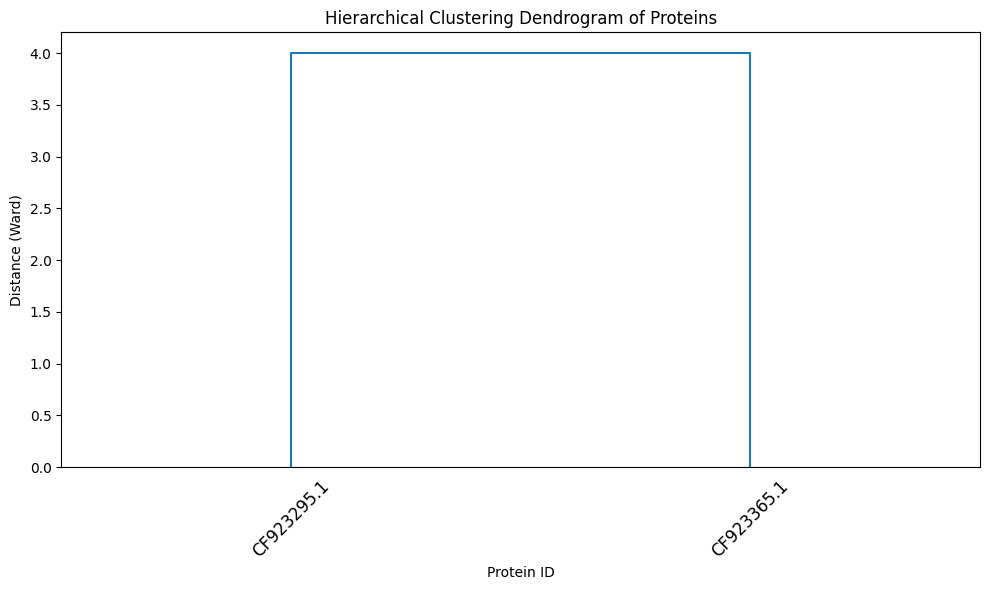


--- Dendrogram Explanation ---
The dendrogram visually represents the relationships between proteins based on
their physiochemical properties. Proteins that join together at lower heights (y-axis)
are more similar to each other. We standardized the data so properties with large numbers
(like Molecular Weight) don't unfairly outweigh properties with small numbers (like Net Charge).


In [13]:
if 'properties_df' in locals() and not properties_df.empty:

    if len(properties_df) < 2:
        print("Need at least 2 proteins to generate a dendrogram.")

    else:
        print(f"Generating dendrogram for {len(properties_df)} proteins...\n")

        # Select the numerical features for clustering
        features = ['Length', 'Molecular_Weight_Da', 'Isoelectric_Point', 'Net_Charge_pH7', 'Extinction_Coeff_Reduced']

        # Set protein ID as index
        clustering_data = properties_df.set_index('Protein_ID')[features]

        # Standardize the features so each property contributes equally to the distance
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(clustering_data)

        # Perform hierarchical clustering using Ward's method
        Z = linkage(scaled_features, method='ward')

        # Plot the dendrogram
        plt.figure(figsize=(10, 6))
        plt.title('Hierarchical Clustering Dendrogram of Proteins')
        plt.xlabel('Protein ID')
        plt.ylabel('Distance (Ward)')

        dendrogram(
            Z,
            labels=clustering_data.index.tolist(),
            leaf_rotation=45.,
            leaf_font_size=12.,
            show_contracted=True
        )

        plt.tight_layout()
        plt.show()

        print("\n--- Dendrogram Explanation ---")
        print("The dendrogram visually represents the relationships between proteins based on")
        print("their physiochemical properties. Proteins that join together at lower heights (y-axis)")
        print("are more similar to each other. We standardized the data so properties with large numbers")
        print("(like Molecular Weight) don't unfairly outweigh properties with small numbers (like Net Charge).")

else:
    print("Properties data not found. Please run the 'Create a Property Dictionary' cell first.")

Figure interpretation: In this dendrogram, your protein sequences of interest are hierarchically organized according to similarity of psychochemical properties. Each *leaf* of the diagram represents one protein, and leaves are connected via branches. The shorter the Ward distance of the branch, the more similar the protein(s) connected.

### Relationship Outputs

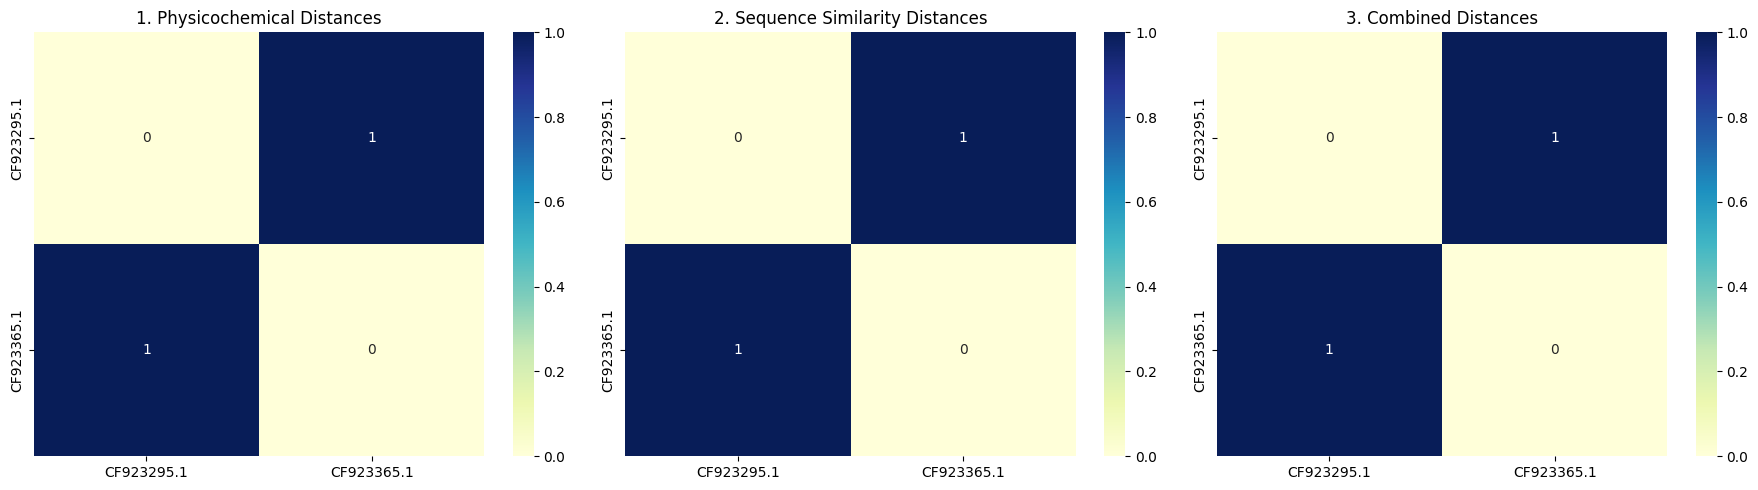


--- Relationship Heatmaps Explanation ---
These heatmaps show the pairwise 'distances' (dissimilarity) between proteins on a 0 to 1 scale.
0 (lighter color) means identical/highly similar, and 1 (darker color) means highly dissimilar.
1. Physicochemical: Distance based on properties like molecular weight, pI, and charge.
2. Sequence Similarity: Distance mathematically derived from your alignment scores.
3. Combined: The average of the physicochemical and sequence distances.


In [14]:
if 'properties_df' in locals() and 'similarity_df' in locals() and len(properties_df) >= 2:

    protein_ids = properties_df['Protein_ID'].tolist()

    # 1. Physicochemical Distance Matrix
    features = ['Length', 'Molecular_Weight_Da', 'Isoelectric_Point', 'Net_Charge_pH7', 'Extinction_Coeff_Reduced']
    clustering_data = properties_df.set_index('Protein_ID')[features]

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(clustering_data)

    # Calculate pairwise euclidean distances and convert to square matrix
    phys_dist_array = pdist(scaled_features, metric='euclidean')
    phys_dist_matrix = squareform(phys_dist_array)

    # Normalize to 0-1
    mm_scaler = MinMaxScaler()
    phys_dist_norm = mm_scaler.fit_transform(phys_dist_matrix)

    # 2. Sequence Similarity Distance Matrix
    # Initialize with high similarity for identical proteins (diagonal)
    seq_sim_matrix = pd.DataFrame(100.0, index=protein_ids, columns=protein_ids)
    for _, row in similarity_df.iterrows():
        p1, p2, sim = row['Protein_1'], row['Protein_2'], row['Similarity_Percentage']
        seq_sim_matrix.loc[p1, p2] = sim
        seq_sim_matrix.loc[p2, p1] = sim

    # Convert similarity to distance
    max_sim = seq_sim_matrix.values.max()
    seq_dist_matrix = max_sim - seq_sim_matrix.values

    # Normalize to 0-1
    seq_dist_norm = mm_scaler.fit_transform(seq_dist_matrix)

    # 3. Combined Distance Matrix
    combined_dist_norm = (phys_dist_norm + seq_dist_norm) / 2.0

    # Plot heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.heatmap(phys_dist_norm, xticklabels=protein_ids, yticklabels=protein_ids, ax=axes[0], cmap='YlGnBu', annot=True)
    axes[0].set_title('1. Physicochemical Distances')

    sns.heatmap(seq_dist_norm, xticklabels=protein_ids, yticklabels=protein_ids, ax=axes[1], cmap='YlGnBu', annot=True)
    axes[1].set_title('2. Sequence Similarity Distances')

    sns.heatmap(combined_dist_norm, xticklabels=protein_ids, yticklabels=protein_ids, ax=axes[2], cmap='YlGnBu', annot=True)
    axes[2].set_title('3. Combined Distances')

    plt.tight_layout()
    plt.show()

    print("\n--- Relationship Heatmaps Explanation ---")
    print("These heatmaps show the pairwise 'distances' (dissimilarity) between proteins on a 0 to 1 scale.")
    print("0 (lighter color) means identical/highly similar, and 1 (darker color) means highly dissimilar.")
    print("1. Physicochemical: Distance based on properties like molecular weight, pI, and charge.")
    print("2. Sequence Similarity: Distance mathematically derived from your alignment scores.")
    print("3. Combined: The average of the physicochemical and sequence distances.")

else:
    print("Required data not found. Please ensure you have run both the property dictionary and sequence similarity cells.")

##Download your results
Now that you are done running the pipeline, run the cell below to download a zip file with the inputs and output of your run.

In [15]:
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import google.colab.files as files

# Imports for re-generating plots
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("Generating output files...")

# 1. Save protein_properties.csv
if 'properties_df' in locals() and not properties_df.empty:
    properties_df.to_csv('protein_properties.csv', index=False)
    print("  - Saved 'protein_properties.csv'")
else:
    print("  - Warning: 'properties_df' not found or empty. Cannot save CSV.")

# 2. Save sequence_similarity.csv
if 'similarity_df' in locals() and not similarity_df.empty:
    similarity_df.to_csv('sequence_similarity.csv', index=False)
    print("  - Saved 'sequence_similarity.csv'")
else:
    print("  - Warning: 'similarity_df' not found or empty. Cannot save CSV.")

# 3. Re-generate and save dendrogram.pdf
if 'properties_df' in locals() and not properties_df.empty and len(properties_df) >= 2:
    features = ['Length', 'Molecular_Weight_Da', 'Isoelectric_Point', 'Net_Charge_pH7', 'Extinction_Coeff_Reduced']
    clustering_data = properties_df.set_index('Protein_ID')[features]
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(clustering_data)
    Z = linkage(scaled_features, method='ward')

    plt.figure(figsize=(10, 6))
    plt.title('Hierarchical Clustering Dendrogram of Proteins')
    plt.xlabel('Protein ID')
    plt.ylabel('Distance (Ward)')
    dendrogram(
        Z,
        labels=clustering_data.index.tolist(),
        leaf_rotation=45.,
        leaf_font_size=12.,
        show_contracted=True
    )
    plt.tight_layout()
    plt.savefig('dendrogram.pdf', bbox_inches='tight')
    plt.close() # Close the plot to prevent it from displaying in the notebook output
    print("  - Saved 'dendrogram.pdf'")
else:
    print("  - Warning: Not enough data in 'properties_df' to generate dendrogram PDF.")

# 4. Re-generate and save relationship_heatmaps.pdf
if 'properties_df' in locals() and 'similarity_df' in locals() and len(properties_df) >= 2:
    protein_ids = properties_df['Protein_ID'].tolist()
    features = ['Length', 'Molecular_Weight_Da', 'Isoelectric_Point', 'Net_Charge_pH7', 'Extinction_Coeff_Reduced']
    clustering_data = properties_df.set_index('Protein_ID')[features]
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(clustering_data)
    phys_dist_array = pdist(scaled_features, metric='euclidean')
    phys_dist_matrix = squareform(phys_dist_array)
    mm_scaler = MinMaxScaler()
    phys_dist_norm = mm_scaler.fit_transform(phys_dist_matrix)

    seq_sim_matrix = pd.DataFrame(100.0, index=protein_ids, columns=protein_ids)
    for _, row in similarity_df.iterrows():
        p1, p2, sim = row['Protein_1'], row['Protein_2'], row['Similarity_Percentage']
        seq_sim_matrix.loc[p1, p2] = sim
        seq_sim_matrix.loc[p2, p1] = sim
    max_sim = seq_sim_matrix.values.max()
    seq_dist_matrix = max_sim - seq_sim_matrix.values
    seq_dist_norm = mm_scaler.fit_transform(seq_dist_matrix)
    combined_dist_norm = (phys_dist_norm + seq_dist_norm) / 2.0

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(phys_dist_norm, xticklabels=protein_ids, yticklabels=protein_ids, ax=axes[0], cmap='YlGnBu', annot=True)
    axes[0].set_title('1. Physicochemical Distances')
    sns.heatmap(seq_dist_norm, xticklabels=protein_ids, yticklabels=protein_ids, ax=axes[1], cmap='YlGnBu', annot=True)
    axes[1].set_title('2. Sequence Similarity Distances')
    sns.heatmap(combined_dist_norm, xticklabels=protein_ids, yticklabels=protein_ids, ax=axes[2], cmap='YlGnBu', annot=True)
    axes[2].set_title('3. Combined Distances')
    plt.tight_layout()
    fig.savefig('relationship_heatmaps.pdf', bbox_inches='tight')
    plt.close(fig) # Close the plot to prevent it from displaying
    print("  - Saved 'relationship_heatmaps.pdf'")
else:
    print("  - Warning: Not enough data in 'properties_df' or 'similarity_df' to generate heatmaps PDF.")

# 5. Create Zip file
output_filename = 'colab_bioinformatics_output.zip'
files_to_zip = []
if os.path.exists('protein_properties.csv'):
    files_to_zip.append('protein_properties.csv')
if os.path.exists('sequence_similarity.csv'):
    files_to_zip.append('sequence_similarity.csv')
if os.path.exists('dendrogram.pdf'):
    files_to_zip.append('dendrogram.pdf')
if os.path.exists('relationship_heatmaps.pdf'):
    files_to_zip.append('relationship_heatmaps.pdf')

if files_to_zip:
    with zipfile.ZipFile(output_filename, 'w') as zf:
        for file_name in files_to_zip:
            zf.write(file_name, os.path.basename(file_name))
    print(f"\nSuccessfully created '{output_filename}' containing: {', '.join(files_to_zip)}")

    # Provide download link
    files.download(output_filename)
else:
    print("\nNo output files were generated to zip.")


Generating output files...
  - Saved 'protein_properties.csv'
  - Saved 'sequence_similarity.csv'
  - Saved 'dendrogram.pdf'
  - Saved 'relationship_heatmaps.pdf'

Successfully created 'colab_bioinformatics_output.zip' containing: protein_properties.csv, sequence_similarity.csv, dendrogram.pdf, relationship_heatmaps.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>